## Import libraries

In [3]:
import pandas as pd
from tqdm import tqdm
import numpy as np
#from haversine import haversine
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import seaborn as sns

## Download data

### Migratory birds

In [4]:
df_migra = pd.read_csv("migra_species_europe_only.csv")
df_migra

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE
0,Numenius phaeopus,2.0,ES,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,36.001314,-5.610797,2017-01-20,S33804365,Traveling
1,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33940654,Traveling
2,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33751745,Traveling
3,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S34018122,Traveling
4,Numenius phaeopus,3.0,ES,Salinas del Carmen,28.367192,-13.869656,2017-01-21,S33908528,Traveling
...,...,...,...,...,...,...,...,...,...
955967,Chlidonias niger,1.0,NL,Pretpier (Scheveningen),52.117923,4.280005,2025-09-16,S273768812,Stationary
955968,Chlidonias niger,1.0,PL,Wojdal gravel pit lake (Zbiornik Wojdal),52.854158,18.075361,2025-09-19,S274163270,Stationary
955969,Chlidonias niger,1.0,GB,Fort Perch Rock,53.442494,-3.040767,2025-10-05,S277528628,Traveling
955970,Chlidonias niger,1.0,IE,Cross Lough,54.198560,-10.077379,2025-10-09,S278224399,Traveling


In [5]:
df_migra["SCIENTIFIC NAME"].unique()

array(['Numenius phaeopus', 'Calidris ferruginea', 'Calidris alba',
       'Calidris minuta', 'Calidris canutus', 'Calidris pugnax',
       'Tringa ochropus', 'Tringa glareola', 'Spatula querquedula',
       'Pernis apivorus', 'Chlidonias niger'], dtype=object)

In [6]:
# convert to datetime
df_migra['OBSERVATION DATE'] = pd.to_datetime(df_migra['OBSERVATION DATE'])

# extract year
df_migra['year'] = df_migra['OBSERVATION DATE'].dt.year

### Native birds

In [7]:
df_native = pd.read_csv("native_species_europe_only.csv")
df_native

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling
2,Dendrocopos major,3.0,ES,LeganÃ©s--Parque Polvoranca,40.325174,-3.796721,2018-01-21,S42131687,Traveling
3,Dendrocopos major,5.0,HR,Hill Crkvenjak,46.092728,16.558564,2018-01-06,S41672345,Traveling
4,Dendrocopos major,2.0,GB,Kilrenny Common,56.236498,-2.686082,2018-06-09,S46534187,Traveling
...,...,...,...,...,...,...,...,...,...
4039471,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-04-09,S106631527,Stationary
4039472,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-05-05,S108980796,Traveling
4039473,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-10-07,S120180143,Incidental
4039474,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861665,Stationary


In [8]:
df_native["SCIENTIFIC NAME"].unique()

array(['Dendrocopos major', 'Strix aluco', 'Parus major',
       'Tringa ochropus', 'Pyrrhula pyrrhula', 'Erithacus rubecula'],
      dtype=object)

In [9]:
df_native["COUNTRY CODE"].unique()

array(['PT', 'UA', 'ES', 'HR', 'GB', 'PL', 'FI', 'NL', 'SE', 'DE', 'FR',
       'IT', 'CZ', 'RS', 'HU', 'DK', 'SI', 'LU', 'BE', 'CH', 'GR', 'NO',
       'BG', 'AT', 'SK', 'LT', 'EE', 'MK', 'MD', 'JE', 'BY', 'RO', 'ME',
       'BA', 'IE', 'LV', 'LI', 'AL', 'IM', 'AD', 'GG', 'FO', 'GI', 'CY',
       'MC', 'SM', 'VA', 'MT', 'IS'], dtype=object)

| Code | Country | Approx. Area (km²) | Bounding Box (Lat min, Lat max, Lon min, Lon max) |
|------|---------|------------------|---------------------------------------------------|
| PT   | Portugal | 92,090 | (36.96, 42.15, -9.50, -6.19) |
| UA   | Ukraine | 603,500 | (44.38, 52.38, 22.15, 40.23) |
| ES   | Spain   | 505,990 | (36.0, 43.79, -9.34, 3.32) |
| HR   | Croatia | 56,594 | (42.38, 46.55, 13.50, 19.40) |
| GB   | United Kingdom | 243,610 | (49.96, 60.85, -8.62, 1.78) |
| PL   | Poland  | 312,696 | (49.00, 54.84, 14.12, 24.15) |
| FI   | Finland | 338,455 | (59.80, 70.09, 20.64, 31.59) |
| NL   | Netherlands | 41,543 | (50.75, 53.55, 3.35, 7.22) |
| SE   | Sweden  | 450,295 | (55.34, 69.06, 11.05, 24.17) |
| DE   | Germany | 357,022 | (47.27, 55.06, 5.87, 15.04) |
| FR   | France  | 643,801 | (41.37, 51.09, -5.14, 9.56) |
| IT   | Italy   | 301,340 | (36.65, 47.09, 6.63, 18.52) |
| CZ   | Czechia | 78,867 | (48.55, 51.06, 12.09, 18.86) |
| RS   | Serbia  | 77,474 | (42.23, 46.19, 18.83, 23.00) |
| HU   | Hungary | 93,028 | (45.74, 48.58, 16.11, 22.90) |
| DK   | Denmark | 42,933 | (54.56, 57.75, 8.09, 12.69) |
| SI   | Slovenia | 20,273 | (45.42, 46.88, 13.38, 16.61) |
| LU   | Luxembourg | 2,586 | (49.44, 50.18, 5.73, 6.53) |
| BE   | Belgium | 30,689 | (49.50, 51.50, 2.54, 6.40) |
| CH   | Switzerland | 41,285 | (45.83, 47.81, 5.96, 10.49) |
| GR   | Greece  | 131,957 | (34.80, 41.75, 19.63, 28.25) |
| NO   | Norway  | 385,207 | (57.99, 71.19, 4.65, 31.08) |
| BG   | Bulgaria | 110,879 | (41.23, 44.23, 22.37, 28.60) |
| AT   | Austria | 83,879 | (46.38, 49.02, 9.53, 17.16) |
| SK   | Slovakia | 49,035 | (47.74, 49.61, 16.84, 22.56) |
| LT   | Lithuania | 65,300 | (53.90, 56.45, 20.95, 26.84) |
| EE   | Estonia | 45,227 | (57.51, 59.67, 21.52, 28.19) |
| MK   | North Macedonia | 25,713 | (40.85, 42.33, 20.45, 22.95) |
| MD   | Moldova | 33,846 | (46.43, 48.49, 26.63, 30.16) |
| JE   | Jersey | 116 | (49.18, 49.24, -2.22, -2.05) |
| BY   | Belarus | 207,600 | (51.26, 56.17, 23.18, 32.77) |
| RO   | Romania | 238,397 | (43.62, 48.26, 20.26, 29.73) |
| ME   | Montenegro | 13,812 | (41.85, 43.55, 18.45, 20.35) |
| BA   | Bosnia & Herzegovina | 51,197 | (42.55, 45.27, 15.73, 19.63) |
| IE   | Ireland | 70,273 | (51.39, 55.43, -10.67, -5.34) |
| LV   | Latvia | 64,589 | (55.67, 58.08, 21.05, 28.24) |
| LI   | Liechtenstein | 160 | (47.05, 47.27, 9.47, 9.64) |
| AL   | Albania | 28,748 | (39.63, 42.66, 19.29, 21.06) |
| IM   | Isle of Man | 572 | (54.08, 54.42, -4.72, -4.33) |
| AD   | Andorra | 468 | (42.42, 42.65, 1.41, 1.79) |
| GG   | Guernsey | 78 | (49.42, 49.48, -2.71, -2.42) |
| FO   | Faroe Islands | 1,399 | (61.39, 62.40, -7.70, -6.39) |
| GI   | Gibraltar | 6.8 | (36.11, 36.15, -5.36, -5.34) |
| CY   | Cyprus | 9,251 | (34.57, 35.67, 32.27, 34.03) |
| MC   | Monaco | 2.02 | (43.72, 43.75, 7.41, 7.43) |
| SM   | San Marino | 61 | (43.89, 43.97, 12.44, 12.50) |
| VA   | Vatican City | 0.44 | (41.90, 41.91, 12.45, 12.46) |
| MT   | Malta | 316 | (35.80, 36.10, 14.20, 14.57) |
| IS   | Iceland | 103,000 | (63.40, 66.50, -25.00, -13.50) |

In [10]:
df_native["OBSERVATION DATE"]

0          2018-01-26
1          2018-12-22
2          2018-01-21
3          2018-01-06
4          2018-06-09
              ...    
4039471    2022-04-09
4039472    2022-05-05
4039473    2022-10-07
4039474    2022-12-12
4039475    2022-12-12
Name: OBSERVATION DATE, Length: 4039476, dtype: object

In [11]:
import pandas as pd

# Add a column specifying migratory/native
df_migra['species_type'] = 'migratory'
df_native['species_type'] = 'native'

#Align columns (if needed)
# Make sure both datasets have the same columns
common_cols = list(set(df_migra.columns) & set(df_native.columns))
df_migra_aligned = df_migra[common_cols]
df_native_aligned = df_native[common_cols]

# concatenate the datasets
df_all = pd.concat([df_migra_aligned, df_native_aligned], ignore_index=True)

#Optional: check the result
print(df_all.head())
print(df_all['species_type'].value_counts())

                                            LOCALITY  LONGITUDE species_type  \
0  Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...  -5.610797    migratory   
1            Marismas del Odiel PNat--Isla de Saltes  -6.943853    migratory   
2            Marismas del Odiel PNat--Isla de Saltes  -6.943853    migratory   
3            Marismas del Odiel PNat--Isla de Saltes  -6.943853    migratory   
4                                 Salinas del Carmen -13.869656    migratory   

      OBSERVATION DATE    SCIENTIFIC NAME SAMPLING EVENT IDENTIFIER  \
0  2017-01-20 00:00:00  Numenius phaeopus                 S33804365   
1  2017-01-16 00:00:00  Numenius phaeopus                 S33940654   
2  2017-01-16 00:00:00  Numenius phaeopus                 S33751745   
3  2017-01-16 00:00:00  Numenius phaeopus                 S34018122   
4  2017-01-21 00:00:00  Numenius phaeopus                 S33908528   

   OBSERVATION COUNT COUNTRY CODE OBSERVATION TYPE   LATITUDE  
0                2.0        

In [12]:
df_all

,LOCALITY,LONGITUDE,species_type,OBSERVATION DATE,SCIENTIFIC NAME,SAMPLING EVENT IDENTIFIER,OBSERVATION COUNT,COUNTRY CODE,OBSERVATION TYPE,LATITUDE
0,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,-5.610797,migratory,2017-01-20 00:00:00,Numenius phaeopus,S33804365,2.0,ES,Traveling,36.001314
1,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S33940654,2.0,ES,Traveling,37.189895
2,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S33751745,2.0,ES,Traveling,37.189895
3,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S34018122,2.0,ES,Traveling,37.189895
4,Salinas del Carmen,-13.869656,migratory,2017-01-21 00:00:00,Numenius phaeopus,S33908528,3.0,ES,Traveling,28.367192
...,...,...,...,...,...,...,...,...,...,...
4995443,Gardens of Vatican City,12.450144,native,2022-04-09,Erithacus rubecula,S106631527,1.0,VA,Stationary,41.903587
4995444,Gardens of Vatican City,12.450144,native,2022-05-05,Erithacus rubecula,S108980796,1.0,VA,Traveling,41.903587
4995445,Gardens of Vatican City,12.450144,native,2022-10-07,Erithacus rubecula,S120180143,1.0,VA,Incidental,41.903587
4995446,Gardens of Vatican City,12.450144,native,2022-12-12,Erithacus rubecula,S123861665,1.0,VA,Stationary,41.903587


In [13]:
df_native

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,species_type
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary,native
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,native
2,Dendrocopos major,3.0,ES,LeganÃ©s--Parque Polvoranca,40.325174,-3.796721,2018-01-21,S42131687,Traveling,native
3,Dendrocopos major,5.0,HR,Hill Crkvenjak,46.092728,16.558564,2018-01-06,S41672345,Traveling,native
4,Dendrocopos major,2.0,GB,Kilrenny Common,56.236498,-2.686082,2018-06-09,S46534187,Traveling,native
...,...,...,...,...,...,...,...,...,...,...
4039471,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-04-09,S106631527,Stationary,native
4039472,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-05-05,S108980796,Traveling,native
4039473,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-10-07,S120180143,Incidental,native
4039474,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861665,Stationary,native


In [14]:
df_migra

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,species_type
0,Numenius phaeopus,2.0,ES,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,36.001314,-5.610797,2017-01-20,S33804365,Traveling,2017,migratory
1,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33940654,Traveling,2017,migratory
2,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33751745,Traveling,2017,migratory
3,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S34018122,Traveling,2017,migratory
4,Numenius phaeopus,3.0,ES,Salinas del Carmen,28.367192,-13.869656,2017-01-21,S33908528,Traveling,2017,migratory
...,...,...,...,...,...,...,...,...,...,...,...
955967,Chlidonias niger,1.0,NL,Pretpier (Scheveningen),52.117923,4.280005,2025-09-16,S273768812,Stationary,2025,migratory
955968,Chlidonias niger,1.0,PL,Wojdal gravel pit lake (Zbiornik Wojdal),52.854158,18.075361,2025-09-19,S274163270,Stationary,2025,migratory
955969,Chlidonias niger,1.0,GB,Fort Perch Rock,53.442494,-3.040767,2025-10-05,S277528628,Traveling,2025,migratory
955970,Chlidonias niger,1.0,IE,Cross Lough,54.198560,-10.077379,2025-10-09,S278224399,Traveling,2025,migratory


In [15]:
df_native['year'] = pd.to_datetime(df_native['OBSERVATION DATE']).dt.year
df_all['year'] = pd.to_datetime(df_all['OBSERVATION DATE']).dt.year
df_migra['year'] = pd.to_datetime(df_migra['OBSERVATION DATE']).dt.year

## Calculate distance from cities

### Insert column tile

In [13]:
tiles = pd.read_csv("../nightlight_tile_year_bounds.csv")
tiles

,tile,year,lon_min,lon_max,lat_min,lat_max
0,h16v03,2017,-7.330252,3.461608,46.832563,57.624422
1,h16v03,2018,-7.330252,3.461608,46.832563,57.624422
2,h16v03,2019,-7.330252,3.461608,46.832563,57.624422
3,h16v03,2020,-7.330252,3.461608,46.832563,57.624422
4,h16v03,2021,-7.330252,3.461608,46.832563,57.624422
...,...,...,...,...,...,...
127,h21v04,2018,46.629045,57.420904,36.040704,46.832563
128,h21v04,2019,46.629045,57.420904,36.040704,46.832563
129,h21v04,2020,46.629045,57.420904,36.040704,46.832563
130,h21v04,2021,46.629045,57.420904,36.040704,46.832563


In [14]:
df_migra["tile"] = None

tiles = tiles[["tile","year","lat_min","lat_max","lon_min","lon_max"]].drop_duplicates()

total = len(tiles)

for i, row in tiles.iterrows():

    tile = row["tile"]
    year = row["year"]

    lat_min = row["lat_min"]
    lat_max = row["lat_max"]
    lon_min = row["lon_min"]
    lon_max = row["lon_max"]

    mask = (
        (df_migra["year"] == year) &
        (df_migra["LATITUDE"] >= lat_min) &
        (df_migra["LATITUDE"] <= lat_max) &
        (df_migra["LONGITUDE"] >= lon_min) &
        (df_migra["LONGITUDE"] <= lon_max)
    )

    df_migra.loc[mask, "tile"] = tile

    print(f"Processed {i+1}/{total} tiles ({tile}, {year})")

Processed 1/132 tiles (h16v03, 2017)
Processed 2/132 tiles (h16v03, 2018)
Processed 3/132 tiles (h16v03, 2019)
Processed 4/132 tiles (h16v03, 2020)
Processed 5/132 tiles (h16v03, 2021)
Processed 6/132 tiles (h16v03, 2022)
Processed 7/132 tiles (h16v04, 2017)
Processed 8/132 tiles (h16v04, 2018)
Processed 9/132 tiles (h16v04, 2019)
Processed 10/132 tiles (h16v04, 2020)
Processed 11/132 tiles (h16v04, 2021)
Processed 12/132 tiles (h16v04, 2022)
Processed 13/132 tiles (h17v02, 2017)
Processed 14/132 tiles (h17v02, 2018)
Processed 15/132 tiles (h17v02, 2019)
Processed 16/132 tiles (h17v02, 2020)
Processed 17/132 tiles (h17v02, 2021)
Processed 18/132 tiles (h17v02, 2022)
Processed 19/132 tiles (h17v03, 2017)
Processed 20/132 tiles (h17v03, 2018)
Processed 21/132 tiles (h17v03, 2019)
Processed 22/132 tiles (h17v03, 2020)
Processed 23/132 tiles (h17v03, 2021)
Processed 24/132 tiles (h17v03, 2022)
Processed 25/132 tiles (h17v04, 2017)
Processed 26/132 tiles (h17v04, 2018)
Processed 27/132 tile

In [26]:
df_migra["tile"].isna().sum().sum()

np.int64(373999)

In [58]:
import geopandas as gpd
from shapely.geometry import Point

birds_gdf = gpd.GeoDataFrame(
    df_migra,
    geometry=gpd.points_from_xy(df_migra['LONGITUDE'], df_migra['LATITUDE']),
    crs="EPSG:4326"
)

In [59]:
birds_gdf

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,geometry
0,Numenius phaeopus,2.0,ES,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,36.001314,-5.610797,2017-01-20,S33804365,Traveling,2017,POINT (-5.6108 36.00131)
1,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33940654,Traveling,2017,POINT (-6.94385 37.18989)
2,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33751745,Traveling,2017,POINT (-6.94385 37.18989)
3,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S34018122,Traveling,2017,POINT (-6.94385 37.18989)
4,Numenius phaeopus,3.0,ES,Salinas del Carmen,28.367192,-13.869656,2017-01-21,S33908528,Traveling,2017,POINT (-13.86966 28.36719)
...,...,...,...,...,...,...,...,...,...,...,...
955967,Chlidonias niger,1.0,NL,Pretpier (Scheveningen),52.117923,4.280005,2025-09-16,S273768812,Stationary,2025,POINT (4.28001 52.11792)
955968,Chlidonias niger,1.0,PL,Wojdal gravel pit lake (Zbiornik Wojdal),52.854158,18.075361,2025-09-19,S274163270,Stationary,2025,POINT (18.07536 52.85416)
955969,Chlidonias niger,1.0,GB,Fort Perch Rock,53.442494,-3.040767,2025-10-05,S277528628,Traveling,2025,POINT (-3.04077 53.44249)
955970,Chlidonias niger,1.0,IE,Cross Lough,54.198560,-10.077379,2025-10-09,S278224399,Traveling,2025,POINT (-10.07738 54.19856)


In [ ]:
!pip install --upgrade osmnx

Note: you may need to restart the kernel to use updated packages.


In [60]:
import requests
import pandas as pd
from shapely.geometry import Point

# Define Overpass query for cities/towns in Europe
query = """
[out:json][timeout:60];
(
  node["place"="city"](36, -10, 43, 0);
  node["place"="town"](36, -10, 43, 0);
);
out body;
"""

url = "http://overpass-api.de/api/interpreter"
response = requests.get(url, params={'data': query})
data = response.json()

# parse results
cities = pd.DataFrame([
    {
        'name': element['tags']['name'],
        'lat': element['lat'],
        'lon': element['lon']
    }
    for element in data['elements'] if 'tags' in element and 'name' in element['tags']
])

# convert to geometry points
cities['geometry'] = cities.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

print(cities.head())

                 name        lat       lon                       geometry
0              Madrid  40.416782 -3.703507    POINT (-3.703507 40.416782)
1  Alacant / Alicante  38.343637 -0.488171  POINT (-0.4881708 38.3436365)
2             Córdoba  37.884581 -4.776014  POINT (-4.7760138 37.8845813)
3              Málaga  36.721303 -4.421637  POINT (-4.4216366 36.7213028)
4        Castro Daire  40.901409 -7.931176  POINT (-7.9311761 40.9014091)


In [61]:
cities

,name,lat,lon,geometry
0,Madrid,40.416782,-3.703507,POINT (-3.703507 40.416782)
1,Alacant / Alicante,38.343637,-0.488171,POINT (-0.4881708 38.3436365)
2,Córdoba,37.884581,-4.776014,POINT (-4.7760138 37.8845813)
3,Málaga,36.721303,-4.421637,POINT (-4.4216366 36.7213028)
4,Castro Daire,40.901409,-7.931176,POINT (-7.9311761 40.9014091)
...,...,...,...,...
1331,Beniel,38.046780,-1.001421,POINT (-1.001421 38.0467801)
1332,Mazarrón,37.598445,-1.315150,POINT (-1.31515 37.5984446)
1333,Agualva-Cacém,38.770262,-9.300722,POINT (-9.3007219 38.7702617)
1334,Llerena,38.237269,-6.015828,POINT (-6.0158279 38.2372687)


In [43]:
overpass_servers = [
    "https://overpass.kumi.systems/api/interpreter",
    "https://lz4.overpass-api.de/api/interpreter",
    "https://overpass.openstreetmap.ru/api/interpreter"
]

In [ ]:
import time
max_retries = 3
for attempt in range(max_retries):
    try:
        response = requests.get(url, params={'data': query}, timeout=200)
        response.raise_for_status()
        data = response.json()
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed for tile {lat_min},{lon_min}: {e}")
        time.sleep(10)
else:
    print(f"Skipping tile {lat_min},{lon_min} after {max_retries} failed attempts")

In [46]:
data = response.json()
data

{'version': 0.6,
 'generator': 'Overpass API 0.7.62.11 87bfad18',
 'osm3s': {'timestamp_osm_base': '2026-03-12T23:15:35Z',
  'copyright': 'The data included in this document is from www.openstreetmap.org. The data is made available under ODbL.'},
 'elements': [{'type': 'node',
   'id': 441183,
   'lat': 37.9755648,
   'lon': 23.7348324,
   'tags': {'addr:country': 'GR',
    'admin_level': '2',
    'alt_name:cs': 'Atény',
    'alt_name:gd': 'Baile na h-Àithne',
    'alt_name:gl': 'Αθήνα',
    'alt_name:uk': 'Атени',
    'capital': 'yes',
    'capital_ISO3166-1': 'yes',
    'ele': '70',
    'int_name': 'Athina',
    'name': 'Αθήνα',
    'name:af': 'Athene',
    'name:am': 'አቴና',
    'name:an': 'Atenas',
    'name:ang': 'Athēnas',
    'name:ar': 'أثينا',
    'name:arc': 'ܐܬܢܘܣ',
    'name:arz': 'اتينا',
    'name:ast': 'Atenes',
    'name:ay': 'Athina',
    'name:az': 'Afina',
    'name:ba': 'Афина',
    'name:bat-smg': 'Atienā',
    'name:be': 'Афіны',
    'name:be-tarask': 'Атэны',
    

In [ ]:
birds_gdf = birds_gdf.to_crs(3857)
cities = cities.to_crs(3857)

In [ ]:
birds_with_city = gpd.sjoin_nearest(
    birds_gdf,
    cities,
    distance_col="distance_to_city"
)

birds_with_city["distance_km"] = birds_with_city["distance_to_city"] / 1000

## Combine nightlights

In [11]:
# df_nightlight_city = pd.read_csv("../nightlight_tile_year_bounds_with_bright_cities.csv")
# df_nightlight_city
df_nightlight_city = pd.read_csv("../nightlight_tile_year_bounds_with_urban_clusters.csv")
df_nightlight_city

,tile,year,lon_min,lon_max,lat_min,lat_max,city_lat_1,city_lon_1,city_lat_2,city_lon_2,city_lat_3,city_lon_3,city_lat_4,city_lon_4,city_lat_5,city_lon_5
0,h16v03,2017,-7.330252,3.461608,46.832563,57.624422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,h16v03,2018,-7.330252,3.461608,46.832563,57.624422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,h16v03,2019,-7.330252,3.461608,46.832563,57.624422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,h16v03,2020,-7.330252,3.461608,46.832563,57.624422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,h16v03,2021,-7.330252,3.461608,46.832563,57.624422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,h21v04,2018,46.629045,57.420904,36.040704,46.832563,36.860951,47.043841,43.008947,47.405392,37.445429,53.439007,43.863230,57.120860,41.497160,56.344533
128,h21v04,2019,46.629045,57.420904,36.040704,46.832563,36.861567,47.043890,43.007742,47.404481,37.441596,53.447507,43.863540,57.121494,41.498093,56.344528
129,h21v04,2020,46.629045,57.420904,36.040704,46.832563,45.156133,52.039269,43.006872,47.405036,37.441709,53.447006,43.864091,57.120038,41.498671,56.345283
130,h21v04,2021,46.629045,57.420904,36.040704,46.832563,45.156273,52.038686,43.008183,47.402700,37.441377,53.446795,43.864574,57.120410,41.498805,56.345899


In [ ]:
#distance_to_city = sqrt((bird_lat - city_lat)**2 + (bird_lon - city_lon)**2)

### Slow method to assign the birds to tiles

In [13]:
def assign_tile(row, tiles_df):
    
    matches = tiles_df[
        (row["LATITUDE"] >= tiles_df["lat_min"]) &
        (row["LATITUDE"] <= tiles_df["lat_max"]) &
        (row["LONGITUDE"] >= tiles_df["lon_min"]) &
        (row["LONGITUDE"] <= tiles_df["lon_max"]) &
        (row["year"] == tiles_df["year"])
    ]
    
    if len(matches) > 0:
        return matches.iloc[0]["tile"]
    
    return None

df_native["tile"] = df_native.apply(assign_tile, axis=1, tiles_df=df_nightlight_city)

KeyboardInterrupt: 

### Fast method to assign birds to tiles

In [12]:
df_native["tile"] = None

tiles = df_nightlight_city[["tile","year","lat_min","lat_max","lon_min","lon_max"]].drop_duplicates()

total = len(tiles)

for i, row in tiles.iterrows():

    tile = row["tile"]
    year = row["year"]

    lat_min = row["lat_min"]
    lat_max = row["lat_max"]
    lon_min = row["lon_min"]
    lon_max = row["lon_max"]

    mask = (
        (df_native["year"] == year) &
        (df_native["LATITUDE"] >= lat_min) &
        (df_native["LATITUDE"] <= lat_max) &
        (df_native["LONGITUDE"] >= lon_min) &
        (df_native["LONGITUDE"] <= lon_max)
    )

    df_native.loc[mask, "tile"] = tile

    print(f"Processed {i+1}/{total} tiles ({tile}, {year})")

Processed 1/132 tiles (h16v03, 2017)
Processed 2/132 tiles (h16v03, 2018)
Processed 3/132 tiles (h16v03, 2019)
Processed 4/132 tiles (h16v03, 2020)
Processed 5/132 tiles (h16v03, 2021)
Processed 6/132 tiles (h16v03, 2022)
Processed 7/132 tiles (h16v04, 2017)
Processed 8/132 tiles (h16v04, 2018)
Processed 9/132 tiles (h16v04, 2019)
Processed 10/132 tiles (h16v04, 2020)
Processed 11/132 tiles (h16v04, 2021)
Processed 12/132 tiles (h16v04, 2022)
Processed 13/132 tiles (h17v02, 2017)
Processed 14/132 tiles (h17v02, 2018)
Processed 15/132 tiles (h17v02, 2019)
Processed 16/132 tiles (h17v02, 2020)
Processed 17/132 tiles (h17v02, 2021)
Processed 18/132 tiles (h17v02, 2022)
Processed 19/132 tiles (h17v03, 2017)
Processed 20/132 tiles (h17v03, 2018)
Processed 21/132 tiles (h17v03, 2019)
Processed 22/132 tiles (h17v03, 2020)
Processed 23/132 tiles (h17v03, 2021)
Processed 24/132 tiles (h17v03, 2022)
Processed 25/132 tiles (h17v04, 2017)
Processed 26/132 tiles (h17v04, 2018)
Processed 27/132 tile

In [13]:
df_native

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,tile
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary,2018,None
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03
2,Dendrocopos major,3.0,ES,LeganÃ©s--Parque Polvoranca,40.325174,-3.796721,2018-01-21,S42131687,Traveling,2018,h16v04
3,Dendrocopos major,5.0,HR,Hill Crkvenjak,46.092728,16.558564,2018-01-06,S41672345,Traveling,2018,h18v04
4,Dendrocopos major,2.0,GB,Kilrenny Common,56.236498,-2.686082,2018-06-09,S46534187,Traveling,2018,h16v03
...,...,...,...,...,...,...,...,...,...,...,...
4039471,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-04-09,S106631527,Stationary,2022,h17v04
4039472,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-05-05,S108980796,Traveling,2022,h17v04
4039473,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-10-07,S120180143,Incidental,2022,h17v04
4039474,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861665,Stationary,2022,h17v04


## Calculate distance to the closest city

In [35]:
city_rows = []

for i in range(1,6):  # assuming 5 brightest cities
    temp = df_nightlight_city[["tile","year",f"city_lat_{i}",f"city_lon_{i}"]].copy()
    
    temp = temp.rename(columns={
        f"city_lat_{i}":"city_lat",
        f"city_lon_{i}":"city_lon"
    })
    
    temp["city_id"] = i
    
    city_rows.append(temp)

df_cities = pd.concat(city_rows, ignore_index=True)

NameError: name 'df_nightlight_city' is not defined

In [17]:
df_cities

,tile,year,city_lat,city_lon,city_id
0,h16v03,2017,48.977445,-6.426433,1
1,h16v03,2018,49.139323,3.169328,1
2,h16v03,2019,49.143819,3.173825,1
3,h16v03,2020,49.148316,3.169328,1
4,h16v03,2021,49.148316,3.169328,1
...,...,...,...,...,...
655,h21v04,2018,41.782872,56.580038,5
656,h21v04,2019,41.778375,56.580038,5
657,h21v04,2020,41.782872,56.580038,5
658,h21v04,2021,41.778375,56.580038,5


In [17]:
df_merge_birdcity = df_native.merge(
    df_cities,
    on=["tile","year"],
    how="left"
)

df_merge_birdcity

MemoryError: Unable to allocate 132. MiB for an array with shape (17329876,) and data type int64

In [21]:
df_cities.isna().sum().sum()

np.int64(120)

In [22]:
from scipy.spatial import cKDTree
import numpy as np
from tqdm import tqdm

df_native["distance_city_km"] = np.nan

groups = df_native.groupby(["tile","year"])

for (tile, year), birds in tqdm(groups):

    cities = df_cities[
        (df_cities["tile"] == tile) &
        (df_cities["year"] == year)
    ]

    cities = cities.dropna(subset=["city_lat","city_lon"])
    
    if len(cities) == 0:
        continue

    city_coords = cities[["city_lat","city_lon"]].to_numpy()
    tree = cKDTree(city_coords)

    bird_coords = birds[["LATITUDE","LONGITUDE"]].to_numpy()

    dist, idx = tree.query(bird_coords, k=1)

    df_native.loc[birds.index, "distance_city_km"] = dist * 111

 90%|█████████ | 92/102 [00:18<00:02,  4.91it/s]


In [23]:
df_native["distance_city_km"].describe()

count    1.249633e+06
mean     2.839891e+02
std      1.862928e+02
min      6.467422e-01
25%      1.523260e+02
50%      2.421351e+02
75%      3.741495e+02
max      1.168383e+03
Name: distance_city_km, dtype: float64

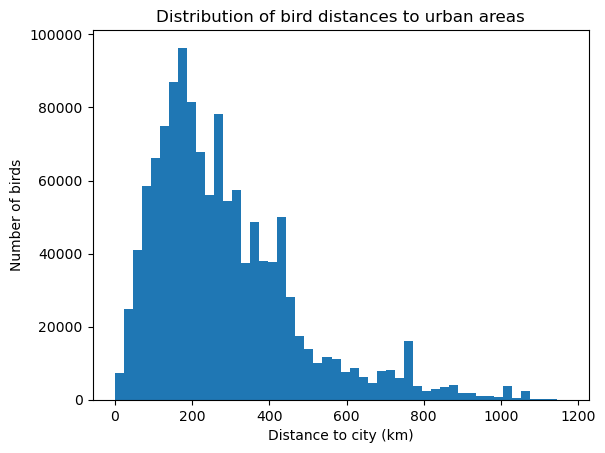

In [26]:
import matplotlib.pyplot as plt

plt.hist(df_native["distance_city_km"], bins=50)
plt.xlabel("Distance to city (km)")
plt.ylabel("Number of birds")
plt.title("Distribution of bird distances to urban areas")
plt.show()

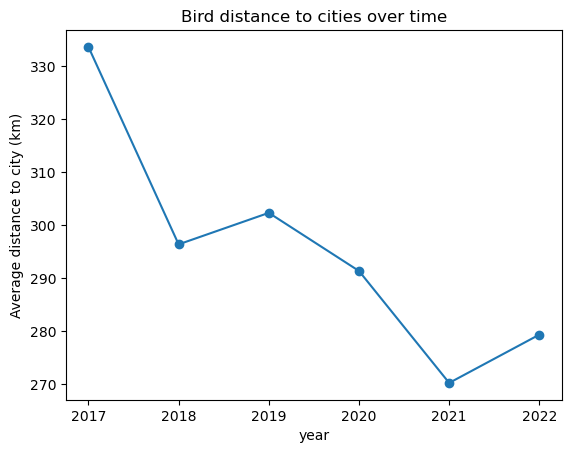

In [27]:
distance_by_year = df_native.groupby("year")["distance_city_km"].mean()

distance_by_year.plot(marker="o")
plt.ylabel("Average distance to city (km)")
plt.title("Bird distance to cities over time")
plt.show()

In [30]:
species_distance = (
    df_native.groupby("SCIENTIFIC NAME")["distance_city_km"]
    .mean()
    .sort_values()
)

species_distance.head(20)

SCIENTIFIC NAME
Dendrocopos major     271.631746
Parus major           280.730229
Erithacus rubecula    292.690071
Pyrrhula pyrrhula     297.100764
Strix aluco           305.057114
Tringa ochropus       308.428487
Name: distance_city_km, dtype: float64

<Axes: xlabel='year', ylabel='distance_city_km'>

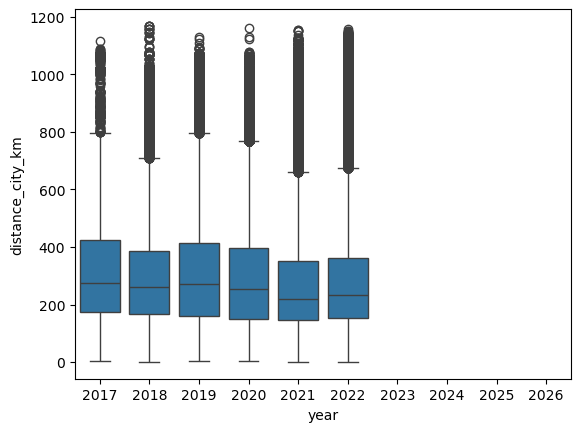

In [31]:
import seaborn as sns

sns.boxplot(
    data=df_native,
    x="year",
    y="distance_city_km"
)

In [33]:
species_affinity = (
    df_native.groupby("SCIENTIFIC NAME")["distance_city_km"]
    .median()
    .sort_values()
)
species_affinity

SCIENTIFIC NAME
Dendrocopos major     229.561658
Pyrrhula pyrrhula     239.759508
Parus major           240.124934
Erithacus rubecula    254.240328
Strix aluco           258.832875
Tringa ochropus       272.617198
Name: distance_city_km, dtype: float64

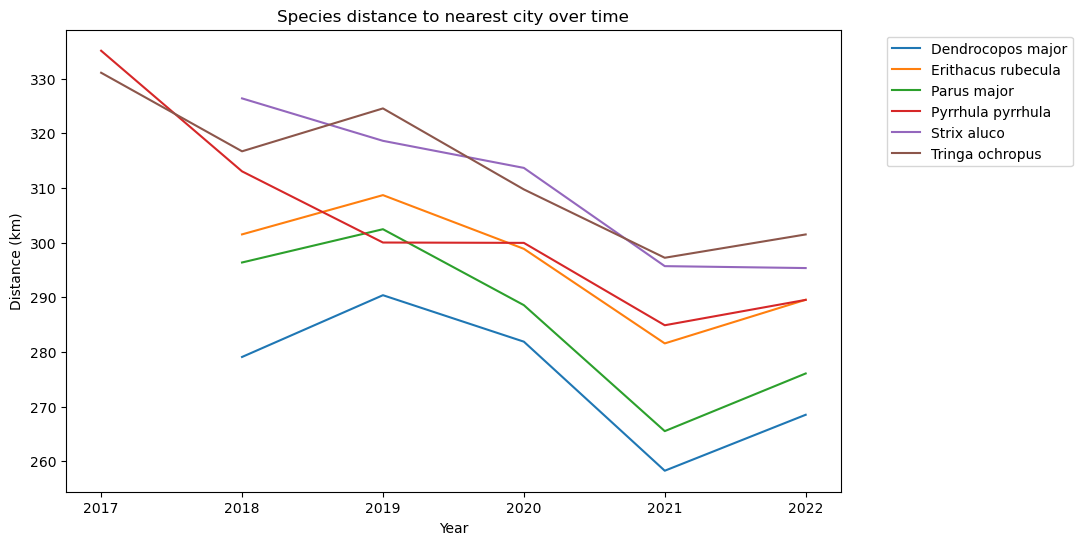

In [35]:
species_year = df_native.groupby(["SCIENTIFIC NAME", "year"])["distance_city_km"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=species_year, x="year", y="distance_city_km", hue="SCIENTIFIC NAME")
plt.title("Species distance to nearest city over time")
plt.ylabel("Distance (km)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    
    R = 6371  # km
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R*c

In [20]:
df_merge_birdcity["distance_km"] = haversine(
    df_merge_birdcity["LATITUDE"],
    df_merge_birdcity["LONGITUDE"],
    df_merge_birdcity["city_lat"],
    df_merge_birdcity["city_lon"]
)

In [21]:
df_merge_birdcity

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,tile,city_lat,city_lon,city_id,distance_km
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary,2018,None,NaN,NaN,NaN,NaN
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03,53.568482,27.792754,1.0,627.505584
2,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03,52.840031,27.424032,2.0,584.459952
3,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03,52.840031,27.433025,3.0,584.024058
4,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03,52.835535,27.428528,4.0,583.895932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17329871,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861666,Stationary,2022,h17v04,39.566044,11.069868,1.0,284.743080
17329872,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861666,Stationary,2022,h17v04,36.575800,10.377391,2.0,618.675660
17329873,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861666,Stationary,2022,h17v04,39.566044,11.065372,3.0,284.897956
17329874,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861666,Stationary,2022,h17v04,43.855808,12.679654,4.0,217.880923


In [22]:
df_merge_birdcity_clean = df_merge_birdcity.dropna(subset=["distance_km"])

#### Memory Error

tiles = df_merge_birdcity_clean['tile'].unique()
df_closest_list = []

for tile in tqdm(tiles, desc="Processing tiles"):
    df_tile = df_merge_birdcity_clean[df_merge_birdcity_clean['tile'] == tile]
    df_closest_tile = df_tile.loc[
        df_tile.groupby(df_tile.index)['distance_km'].idxmin()
    ]
    df_closest_list.append(df_closest_tile)

df_closest = pd.concat(df_closest_list, ignore_index=True)

### Works

In [23]:
# Prepare city coordinates and year
city_coords = []
city_year = []

for idx, row in df_nightlight_city.iterrows():
    year = row['year']
    for i in range(1,6):  # 5 brightest cities
        lat = row[f'bright_lat_{i}']
        lon = row[f'bright_lon_{i}']
        city_coords.append([lat, lon])
        city_year.append(year)

city_coords = np.array(city_coords)
city_year = np.array(city_year)

# Prepare bird coordinates
bird_coords = df_native[['LATITUDE','LONGITUDE']].to_numpy()
bird_years = df_native['year'].to_numpy()

# Store nearest distances
nearest_distance = np.full(len(df_native), np.nan)

# Process year by year to avoid wrong matches
for yr in np.unique(bird_years):
    bird_mask = bird_years == yr
    birds_y = bird_coords[bird_mask]

    city_mask = city_year == yr
    cities_y = city_coords[city_mask]

    if len(cities_y) == 0:
        continue

    # Build KDTree for this year
    tree = cKDTree(cities_y)

    # Query nearest city for each bird
    dist, idx = tree.query(birds_y, k=1)
    
    # Approximate distance: convert degrees to km (rough)
    # 1 degree ~ 111 km
    nearest_distance[bird_mask] = dist * 111

# Add to dataframe
df_native['distance_to_city_km'] = nearest_distance

In [26]:
df_native

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,tile,distance_to_city_km
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary,2018,None,818.618065
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,2018,h19v03,302.640350
2,Dendrocopos major,3.0,ES,LeganÃ©s--Parque Polvoranca,40.325174,-3.796721,2018-01-21,S42131687,Traveling,2018,h16v04,817.223024
3,Dendrocopos major,5.0,HR,Hill Crkvenjak,46.092728,16.558564,2018-01-06,S41672345,Traveling,2018,h18v04,344.628101
4,Dendrocopos major,2.0,GB,Kilrenny Common,56.236498,-2.686082,2018-06-09,S46534187,Traveling,2018,h16v03,1020.274647
...,...,...,...,...,...,...,...,...,...,...,...,...
4039471,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-04-09,S106631527,Stationary,2022,h17v04,218.188987
4039472,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-05-05,S108980796,Traveling,2022,h17v04,218.188987
4039473,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-10-07,S120180143,Incidental,2022,h17v04,218.188987
4039474,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861665,Stationary,2022,h17v04,218.188987


!!!! check for duplicates

## Distance bird - city

In [15]:
species_stats = df_native.groupby("SCIENTIFIC NAME")["distance_city_km"].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).sort_values("mean")
print(species_stats)

KeyError: 'Column not found: distance_city_km'

### Trends over years (not reliable)

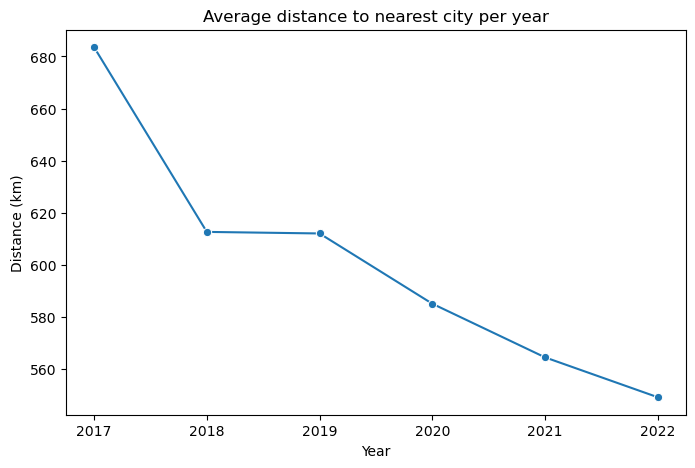

In [32]:
yearly_stats = df_native.groupby("year")["distance_to_city_km"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_stats, x="year", y="distance_to_city_km", marker='o')
plt.title("Average distance to nearest city per year")
plt.ylabel("Distance (km)")
plt.xlabel("Year")
plt.show()

### Spiecies year trends

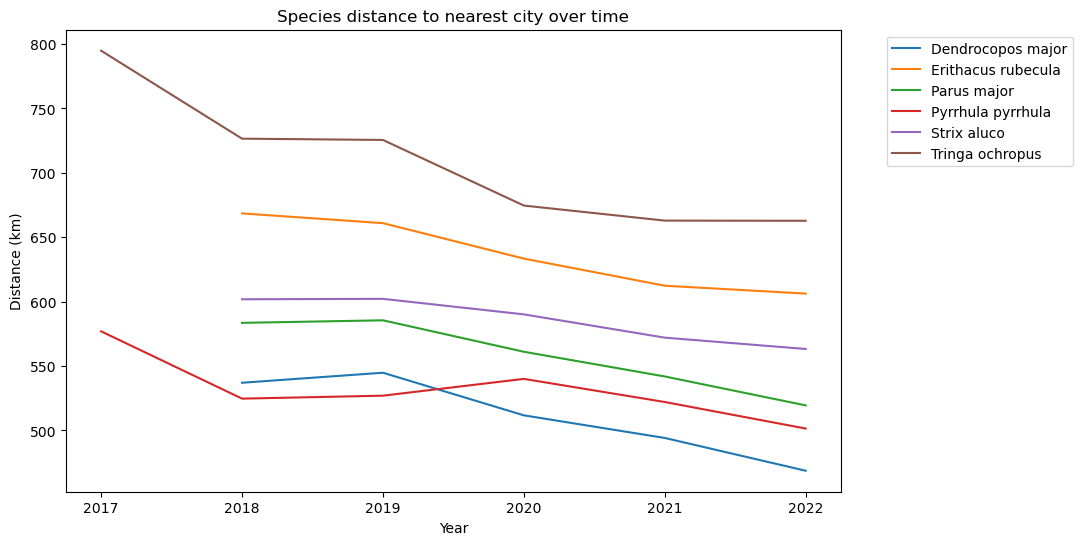

In [34]:
species_year = df_native.groupby(["SCIENTIFIC NAME", "year"])["distance_to_city_km"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=species_year, x="year", y="distance_to_city_km", hue="SCIENTIFIC NAME")
plt.title("Species distance to nearest city over time")
plt.ylabel("Distance (km)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

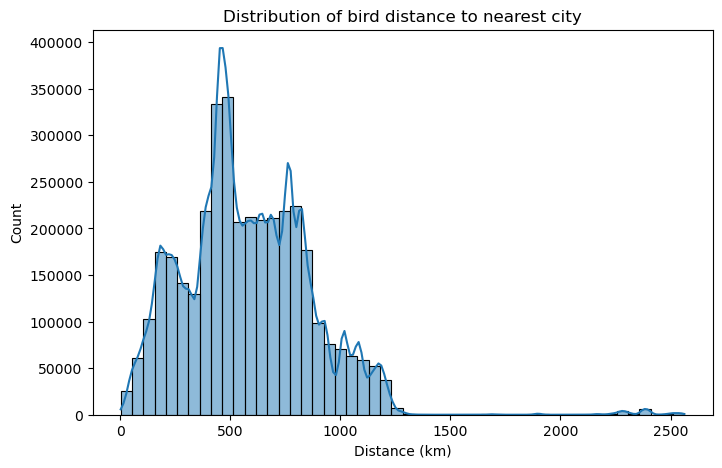

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df_native['distance_to_city_km'], bins=50, kde=True)
plt.title("Distribution of bird distance to nearest city")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.show()

### Top pixels move cloder to the birds?

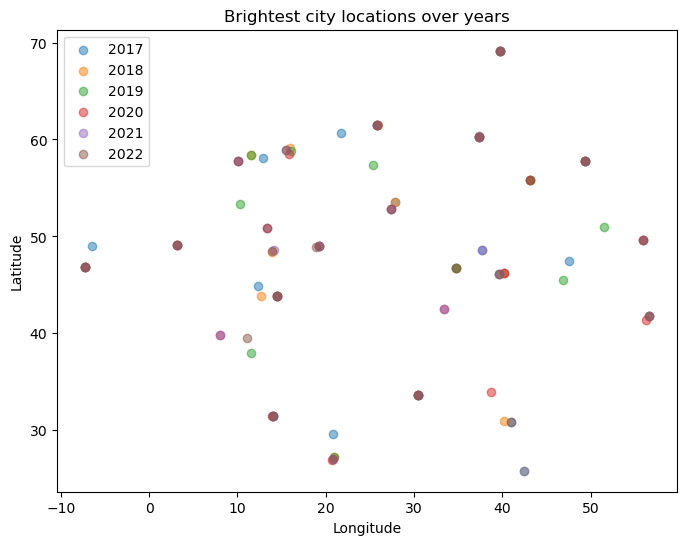

In [36]:
plt.figure(figsize=(8,6))
for year in sorted(df_nightlight_city['year'].unique()):
    cities_y = df_nightlight_city[df_nightlight_city['year']==year]
    plt.scatter(cities_y['bright_lon_1'], cities_y['bright_lat_1'], label=year, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Brightest city locations over years")
plt.legend()
plt.show()

In [37]:
df_nightlight_city.groupby('year').size()

year
2017    22
2018    22
2019    22
2020    22
2021    22
2022    22
dtype: int64

### Problems with this approach

**Tile-Year Matching Issue**

In your KDTree or merge, you assigned bright cities per year based on the year in the bird dataset.

If your nightlight dataset has more cities in later years, birds that are in areas that previously had no bright city might suddenly be matched with a closer city in later years.

This will artificially decrease the distance, even though cities are “growing.”

**Brightest Pixel Detection**

Currently, you pick the top N brightest pixels per tile per year.

If the brightest pixels shift toward existing bird locations (or spread), the algorithm will always pick the closest of those pixels.

The “distance” metric reflects closest bright pixel, not city expansion.

**Birds Distribution Changes**

The birds observed each year may not be exactly the same locations and counts.

If later years have more observations closer to cities, the average distance decreases naturally.

**Degrees $\rightarrow$ km Conversion Approximation**

Using lat/lon × 111 km is a rough approximation.

If the tiles cover high-latitude regions, distances can appear smaller than actual.

## New distance birds

In [16]:
# Load European cities
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip"
import geopandas as gpd
world = gpd.read_file(url)
europe = world[world.geometry.x.between(-25, 45) & world.geometry.y.between(34, 72)]
cities = europe[['NAME', 'ADM0NAME', 'geometry']].copy()
cities['lon'] = cities.geometry.x
cities['lat'] = cities.geometry.y
cities = cities.drop(columns='geometry').reset_index(drop=True)


In [17]:
cities

,NAME,ADM0NAME,lon,lat
0,L'Ariana,Tunisia,10.199998,36.866673
1,Jendouba,Tunisia,8.749999,36.500004
2,Kasserine,Tunisia,8.716698,35.216703
3,Sdid Bouzid,Tunisia,9.500004,35.016696
4,Siliana,Tunisia,9.383302,36.083304
...,...,...,...,...
1143,London,United Kingdom,-0.118668,51.501941
1144,Istanbul,Turkey,28.974277,41.017602
1145,Moscow,Russia,37.613577,55.754110
1146,Rome,Italy,12.481313,41.897902


In [18]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# build KD-Tree
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# query nearest city
birds_rad = np.radians(df_all[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# assign results
df_all['closest_city'] = cities['NAME'].iloc[indices].values
df_all['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_all['distance_km'] = np.round(distances * 6371, 2)

df_all["city_lat"] = cities["lat"].iloc[indices].values
df_all["city_lon"] = cities["lon"].iloc[indices].values

df_all

,LOCALITY,LONGITUDE,species_type,OBSERVATION DATE,SCIENTIFIC NAME,SAMPLING EVENT IDENTIFIER,OBSERVATION COUNT,COUNTRY CODE,OBSERVATION TYPE,LATITUDE,year,closest_city,closest_city_country,distance_km,city_lat,city_lon
0,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,-5.610797,migratory,2017-01-20 00:00:00,Numenius phaeopus,S33804365,2.0,ES,Traveling,36.001314,2017,Algeciras,Spain,22.80,36.131882,-5.452660
1,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S33940654,2.0,ES,Traveling,37.189895,2017,Huelva,Spain,6.90,37.250374,-6.929949
2,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S33751745,2.0,ES,Traveling,37.189895,2017,Huelva,Spain,6.90,37.250374,-6.929949
3,Marismas del Odiel PNat--Isla de Saltes,-6.943853,migratory,2017-01-16 00:00:00,Numenius phaeopus,S34018122,2.0,ES,Traveling,37.189895,2017,Huelva,Spain,6.90,37.250374,-6.929949
4,Salinas del Carmen,-13.869656,migratory,2017-01-21 00:00:00,Numenius phaeopus,S33908528,3.0,ES,Traveling,28.367192,2017,Rabat,Morocco,1003.72,34.025307,-6.836408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995443,Gardens of Vatican City,12.450144,native,2022-04-09,Erithacus rubecula,S106631527,1.0,VA,Stationary,41.903587,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995444,Gardens of Vatican City,12.450144,native,2022-05-05,Erithacus rubecula,S108980796,1.0,VA,Traveling,41.903587,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995445,Gardens of Vatican City,12.450144,native,2022-10-07,Erithacus rubecula,S120180143,1.0,VA,Incidental,41.903587,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4995446,Gardens of Vatican City,12.450144,native,2022-12-12,Erithacus rubecula,S123861665,1.0,VA,Stationary,41.903587,2022,Vatican City,Vatican,0.36,41.903282,12.453387


In [19]:
# build KD-Tree
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# query nearest city
birds_rad = np.radians(df_native[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# assign results
df_native['closest_city'] = cities['NAME'].iloc[indices].values
df_native['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_native['distance_km'] = np.round(distances * 6371, 2)

df_native["city_lat"] = cities["lat"].iloc[indices].values
df_native["city_lon"] = cities["lon"].iloc[indices].values

df_native

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,species_type,year,closest_city,closest_city_country,distance_km,city_lat,city_lon
0,Dendrocopos major,1.0,PT,PN Serra de SÃ£o Mamede--Cana Flexa,39.461957,-7.511044,2018-01-26,S42251764,Stationary,native,2018,Portalegre,Portugal,21.48,39.290004,-7.423001
1,Dendrocopos major,1.0,UA,3-Ñ Ð¾Ð±ÑÐµÐ·Ð´Ð½Ð°Ñ Ð´Ð¾ÑÐ¾Ð³Ð° Ð¡Ð²ÐµÑÐ...,49.052457,33.215695,2018-12-22,S50893829,Traveling,native,2018,Kremenchuk,Ukraine,24.04,49.083527,33.429628
2,Dendrocopos major,3.0,ES,LeganÃ©s--Parque Polvoranca,40.325174,-3.796721,2018-01-21,S42131687,Traveling,native,2018,Madrid,Spain,15.05,40.401972,-3.685297
3,Dendrocopos major,5.0,HR,Hill Crkvenjak,46.092728,16.558564,2018-01-06,S41672345,Traveling,native,2018,Zagreb,Croatia,70.12,45.800007,15.999995
4,Dendrocopos major,2.0,GB,Kilrenny Common,56.236498,-2.686082,2018-06-09,S46534187,Traveling,native,2018,Dundee,United Kingdom,43.53,56.470389,-3.000008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4039471,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-04-09,S106631527,Stationary,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4039472,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-05-05,S108980796,Traveling,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4039473,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-10-07,S120180143,Incidental,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387
4039474,Erithacus rubecula,1.0,VA,Gardens of Vatican City,41.903587,12.450144,2022-12-12,S123861665,Stationary,native,2022,Vatican City,Vatican,0.36,41.903282,12.453387


In [20]:
# build KD-Tree
cities_rad = np.radians(cities[['lat', 'lon']].values)
tree = cKDTree(cities_rad)

# query nearest city
birds_rad = np.radians(df_migra[['LATITUDE', 'LONGITUDE']].values)
distances, indices = tree.query(birds_rad, k=1)

# assign results
df_migra['closest_city'] = cities['NAME'].iloc[indices].values
df_migra['closest_city_country'] = cities['ADM0NAME'].iloc[indices].values
df_migra['distance_km'] = np.round(distances * 6371, 2)

df_migra["city_lat"] = cities["lat"].iloc[indices].values
df_migra["city_lon"] = cities["lon"].iloc[indices].values

df_migra

,SCIENTIFIC NAME,OBSERVATION COUNT,COUNTRY CODE,LOCALITY,LATITUDE,LONGITUDE,OBSERVATION DATE,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,year,species_type,closest_city,closest_city_country,distance_km,city_lat,city_lon
0,Numenius phaeopus,2.0,ES,Isla Tarifa.ES-Tarifa - 36.001x-5.611 - 20 Jan...,36.001314,-5.610797,2017-01-20,S33804365,Traveling,2017,migratory,Algeciras,Spain,22.80,36.131882,-5.452660
1,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33940654,Traveling,2017,migratory,Huelva,Spain,6.90,37.250374,-6.929949
2,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S33751745,Traveling,2017,migratory,Huelva,Spain,6.90,37.250374,-6.929949
3,Numenius phaeopus,2.0,ES,Marismas del Odiel PNat--Isla de Saltes,37.189895,-6.943853,2017-01-16,S34018122,Traveling,2017,migratory,Huelva,Spain,6.90,37.250374,-6.929949
4,Numenius phaeopus,3.0,ES,Salinas del Carmen,28.367192,-13.869656,2017-01-21,S33908528,Traveling,2017,migratory,Rabat,Morocco,1003.72,34.025307,-6.836408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955967,Chlidonias niger,1.0,NL,Pretpier (Scheveningen),52.117923,4.280005,2025-09-16,S273768812,Stationary,2025,migratory,The Hague,Netherlands,4.36,52.080037,4.269961
955968,Chlidonias niger,1.0,PL,Wojdal gravel pit lake (Zbiornik Wojdal),52.854158,18.075361,2025-09-19,S274163270,Stationary,2025,migratory,Inowrocław,Poland,21.10,52.779942,18.249986
955969,Chlidonias niger,1.0,GB,Fort Perch Rock,53.442494,-3.040767,2025-10-05,S277528628,Traveling,2025,migratory,Liverpool,United Kingdom,9.70,53.405068,-2.961934
955970,Chlidonias niger,1.0,IE,Cross Lough,54.198560,-10.077379,2025-10-09,S278224399,Traveling,2025,migratory,Galway,Ireland,153.90,53.272393,-9.048812


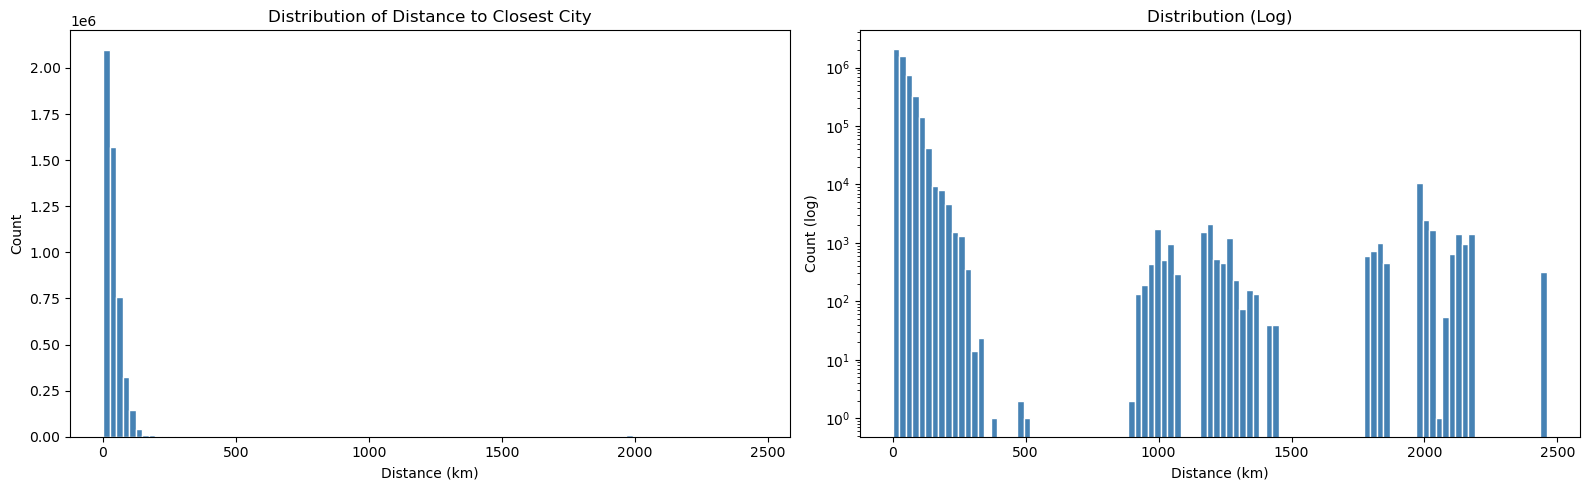

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_all['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_all['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

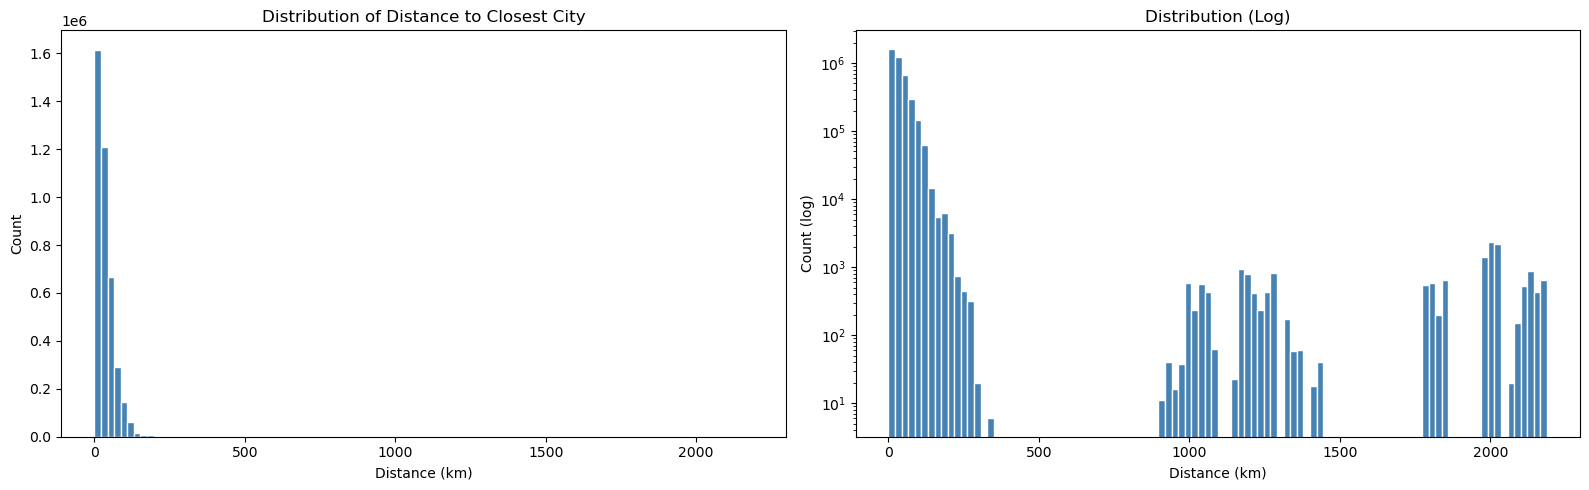

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_native['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_native['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

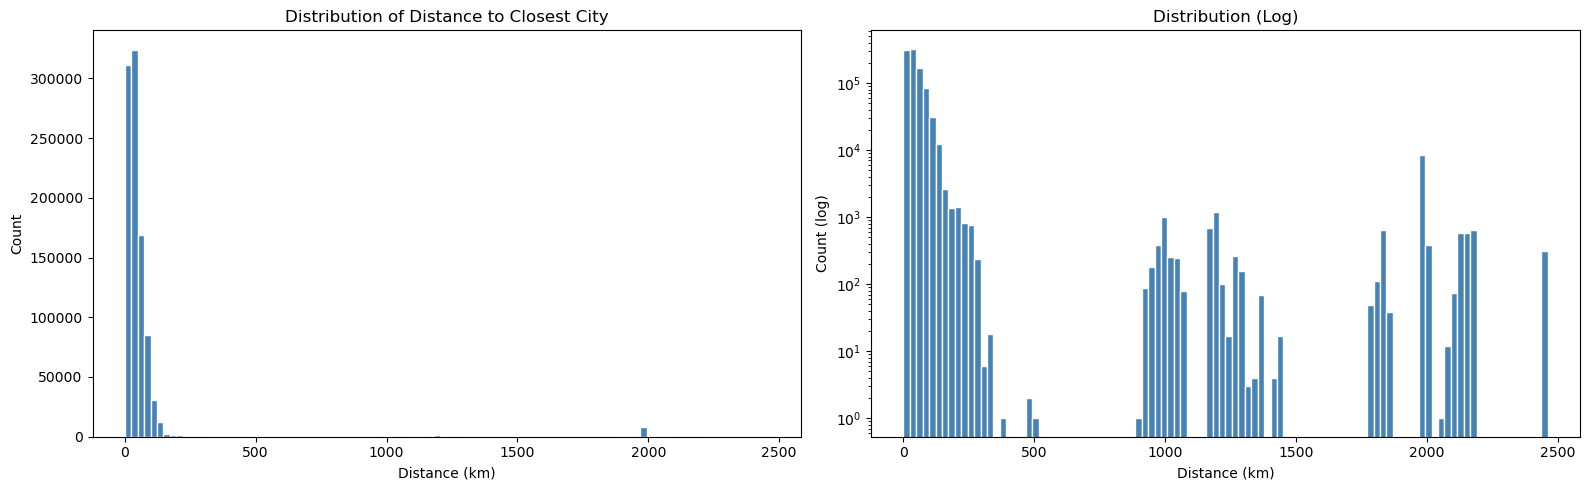

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# histogram
axes[0].hist(df_migra['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance to Closest City')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Count')

# log scale histogram (useful if data is right-skewed)
axes[1].hist(df_migra['distance_km'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (Log)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Count (log)')


plt.tight_layout()
plt.savefig("distance_distribution.png", dpi=150)
plt.show()

In [21]:
print(df_all['distance_km'].describe()) 
print(f"\nMedian:  {df_all['distance_km'].median():.2f} km")
print(f"Skewness: {df_all['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_all['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_all['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_all['distance_km'] <= 100).mean()*100:.1f}%")

count    4.995448e+06
mean     4.759190e+01
std      1.445540e+02
min      2.000000e-02
25%      1.435000e+01
50%      2.977000e+01
75%      5.057000e+01
max      2.460870e+03
Name: distance_km, dtype: float64

Median:  29.77 km
Skewness: 12.28
% within 10km:  16.3%
% within 50km:  74.2%
% within 100km: 95.4%


In [22]:
print(df_native['distance_km'].describe())
print(f"\nMedian:  {df_native['distance_km'].median():.2f} km")
print(f"Skewness: {df_native['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_native['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_native['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_native['distance_km'] <= 100).mean()*100:.1f}%")

count    4.039476e+06
mean     4.175045e+01
std      1.131613e+02
min      2.000000e-02
25%      1.320000e+01
50%      2.829000e+01
75%      4.897000e+01
max      2.188640e+03
Name: distance_km, dtype: float64

Median:  28.29 km
Skewness: 15.18
% within 10km:  18.2%
% within 50km:  75.9%
% within 100km: 95.9%


In [23]:
print(df_migra['distance_km'].describe())
print(f"\nMedian:  {df_migra['distance_km'].median():.2f} km")
print(f"Skewness: {df_migra['distance_km'].skew():.2f}")
print(f"% within 10km:  {(df_migra['distance_km'] <= 10).mean()*100:.1f}%")
print(f"% within 50km:  {(df_migra['distance_km'] <= 50).mean()*100:.1f}%")
print(f"% within 100km: {(df_migra['distance_km'] <= 100).mean()*100:.1f}%")

count    955972.000000
mean         72.275063
std         233.084836
min           0.050000
25%          20.590000
50%          35.590000
75%          58.200000
max        2460.870000
Name: distance_km, dtype: float64

Median:  35.59 km
Skewness: 7.72
% within 10km:  8.5%
% within 50km:  67.2%
% within 100km: 93.1%


In [25]:
# check what's driving the outliers
outliers = df_all[df_all['distance_km'] > 500]
print(outliers['COUNTRY CODE'].value_counts())
print(outliers[['LATITUDE', 'LONGITUDE', 'COUNTRY CODE', 'distance_km']].head(20))

COUNTRY CODE
PT    23442
ES     9688
Name: count, dtype: int64
     LATITUDE  LONGITUDE COUNTRY CODE  distance_km
4   28.367192 -13.869656           ES      1003.72
5   28.367192 -13.869656           ES      1003.72
16  38.524264 -28.628097           PT      2166.33
17  38.393810 -28.254347           PT      2124.98
18  38.393810 -28.254347           PT      2124.98
19  38.393810 -28.254347           PT      2124.98
20  38.393810 -28.254347           PT      2124.98
21  38.393810 -28.254347           PT      2124.98
22  38.393810 -28.254347           PT      2124.98
23  38.535062 -28.530885           PT      2155.51
24  38.706343 -27.047567           PT      1990.47
25  38.706343 -27.047567           PT      1990.47
26  32.742671 -16.701794           PT      1031.21
27  32.742671 -16.701794           PT      1031.21
32  28.375467 -16.864716           ES      1279.89
36  38.522603 -28.668768           PT      2170.86
37  38.522603 -28.668768           PT      2170.86
38  38.706343 -27.0

In [26]:
# check what's driving the outliers
outliers = df_native[df_native['distance_km'] > 500]
print(outliers['COUNTRY CODE'].value_counts())
print(outliers[['LATITUDE', 'LONGITUDE', 'COUNTRY CODE', 'distance_km']].head(20))

COUNTRY CODE
PT    11394
ES     5109
Name: count, dtype: int64
       LATITUDE  LONGITUDE COUNTRY CODE  distance_km
68    27.988852 -15.593290           ES      1182.65
130   28.160268 -16.642399           ES      1270.53
394   28.190192 -16.665776           ES      1271.06
716   28.190192 -16.665776           ES      1271.06
867   27.961783 -15.619554           ES      1186.77
870   28.190192 -16.665776           ES      1271.06
1236  28.165900 -16.638700           ES      1269.85
1563  28.006094 -15.599630           ES      1182.15
1581  28.190192 -16.665776           ES      1271.06
1584  28.026758 -15.612892           ES      1182.07
1700  28.257575 -16.769551           ES      1277.21
1933  28.190192 -16.665776           ES      1271.06
2217  28.155805 -16.637995           ES      1270.36
2605  27.951713 -15.651890           ES      1190.36
2883  28.165900 -16.638700           ES      1269.85
3497  28.190192 -16.665776           ES      1271.06
3653  27.965669 -15.595093          

In [27]:
# check what's driving the outliers
outliers = df_migra[df_migra['distance_km'] > 500]
print(outliers['COUNTRY CODE'].value_counts())
print(outliers[['LATITUDE', 'LONGITUDE', 'COUNTRY CODE', 'distance_km']].head(20))

COUNTRY CODE
PT    12048
ES     4579
Name: count, dtype: int64
     LATITUDE  LONGITUDE COUNTRY CODE  distance_km
4   28.367192 -13.869656           ES      1003.72
5   28.367192 -13.869656           ES      1003.72
16  38.524264 -28.628097           PT      2166.33
17  38.393810 -28.254347           PT      2124.98
18  38.393810 -28.254347           PT      2124.98
19  38.393810 -28.254347           PT      2124.98
20  38.393810 -28.254347           PT      2124.98
21  38.393810 -28.254347           PT      2124.98
22  38.393810 -28.254347           PT      2124.98
23  38.535062 -28.530885           PT      2155.51
24  38.706343 -27.047567           PT      1990.47
25  38.706343 -27.047567           PT      1990.47
26  32.742671 -16.701794           PT      1031.21
27  32.742671 -16.701794           PT      1031.21
32  28.375467 -16.864716           ES      1279.89
36  38.522603 -28.668768           PT      2170.86
37  38.522603 -28.668768           PT      2170.86
38  38.706343 -27.0

In [28]:
df_all['is_remote'] = (df_all['distance_km'] > 100).astype(int)
df_native['is_remote'] = (df_native['distance_km'] > 100).astype(int)
df_migra['is_remote'] = (df_migra['distance_km'] > 100).astype(int)

In [29]:
df_native["is_remote"]

0          0
1          0
2          0
3          0
4          0
          ..
4039471    0
4039472    0
4039473    0
4039474    0
4039475    0
Name: is_remote, Length: 4039476, dtype: int64

In [30]:
df_all.to_csv("all_birds_city.csv", index=False)
df_native.to_csv("native_birds_city.csv", index=False)
df_migra.to_csv("migra_birds_city.csv", index=False)

In [99]:
df_native['closest_city'].nunique()

816